In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, rt_utils, coro_utils


INFO:numexpr.utils:NumExpr defaulting to 12 threads.
/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
data_path = Path('../data/20260409')

In [3]:
calib_data = utils.load_pickle(data_path/'calib_data.pkl')

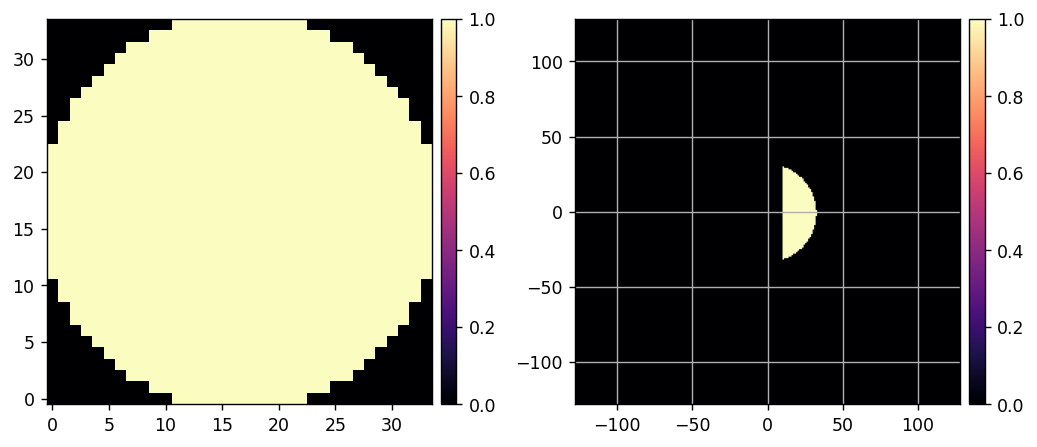

In [55]:
response_cube = calib_data['response_cube']
calib_modes = calib_data['calib_modes']
xshift = calib_data['xshift']
yshift = calib_data['yshift']

Nmodes = response_cube.shape[0]
Nprobes = response_cube.shape[1]
Ncamsci = response_cube.shape[2]
camsci_pxscl_lamDc = 0.307
Nact = 34

dm_mask = dm.create_mask(Nact=Nact)
iwa = 3
owa = 10
rotation = 0
dh_mask = utils.create_annular_mask(
    Ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=xshift,
    y_shift=yshift,
    rotation=rotation,
    # return_np=1,
)
Npix = int(dh_mask.sum())

response_matrix = iefc.make_response_matrix(response_cube, dh_mask)
utils.imshow(
    [dm_mask, dh_mask],
    pxscls=[None, 1],
    grids=[None, 1],
)



In [56]:
reload(utils)
P, U, s, Vt = utils.tikhonov_inverse(response_matrix, 1e-3, return_all=1)

In [27]:
U.T.shape, Npix

((1024, 3066), 1022)

In [53]:
dm_modes = xp.zeros((Nmodes, Nact, Nact))
wfs_modes = xp.zeros((Nmodes, Nprobes, Ncamsci, Ncamsci))
for i in range(Nmodes):
    dm_modes[i, dm_mask] = Vt.dot(calib_modes[:, dm_mask])[i]
    for j in range(Nprobes):
        wfs_modes[i, j, dh_mask] = U.T[i, j*Npix:(j+1)*Npix] 

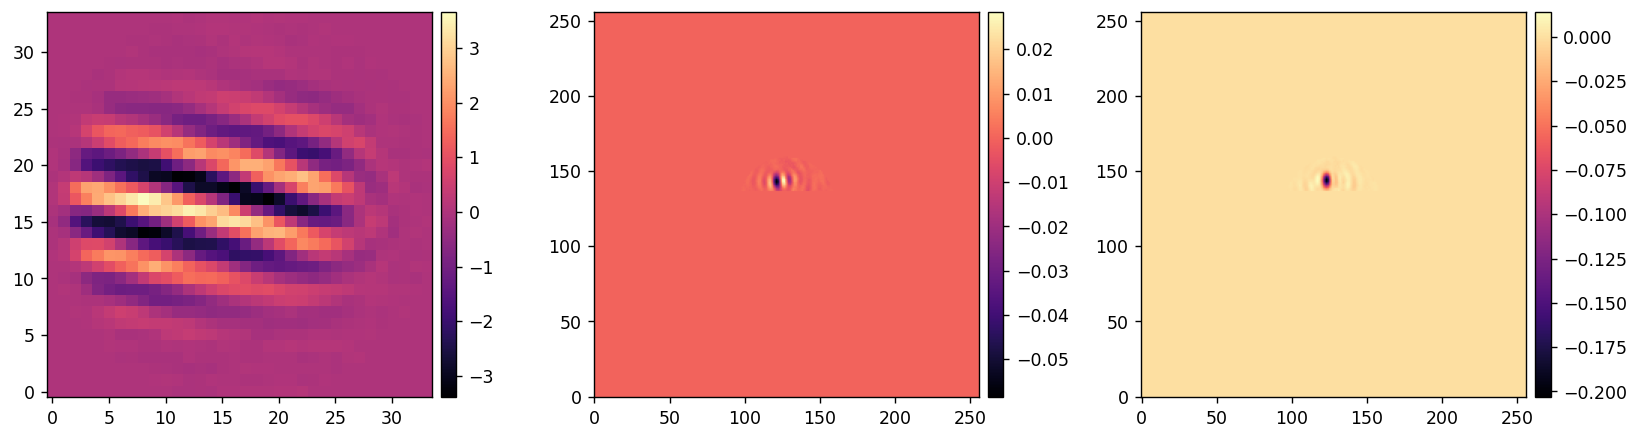

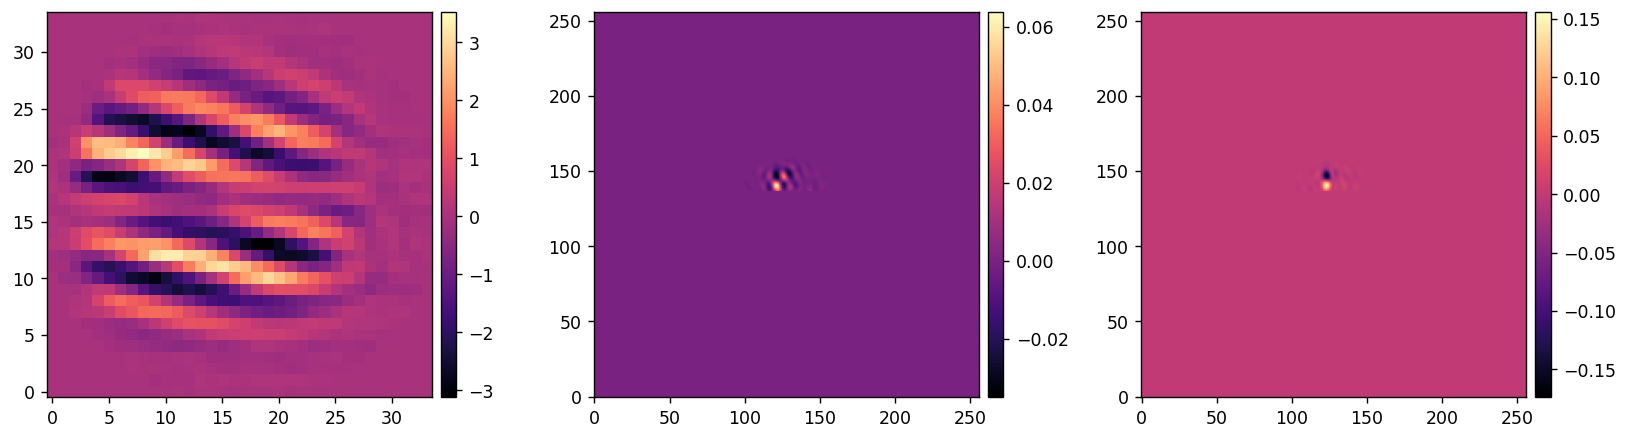

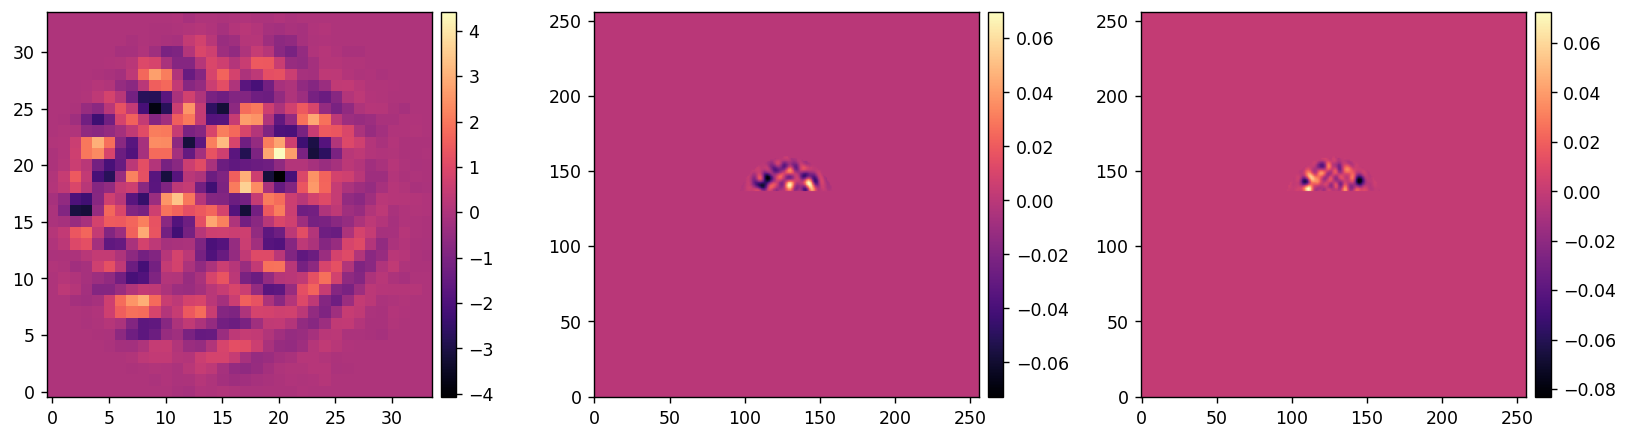

In [54]:
mode_inds = [0, 1, 50]
for i in range(len(mode_inds)):
    ind = mode_inds[i]
    utils.imshow(
        [dm_modes[ind], wfs_modes[ind,0], wfs_modes[ind,2]],
    )